# Smallest stiffness eigenvalue versus strain — SIM 5140 family

This notebook analyzes the SIM 5140–5149 ST1000 chevron-pair snap-through family (neo-Hookean material) directly from the compact lite results in `I001_Results/LITE/SIM_*/`. It reads only `t` and `eigenvalue` from each `mode0.npz`; the large eigenvector array is not loaded. When available, `curves.npz` supplies the global tension/compression-efficiency ratio at the first retained eigenvalue zero crossing.

Step 1 applies a 5 mm displacement over a 20 mm specimen dimension, so nominal compressive strain is `0.25 * t`. Complete histories contain 401 snapshots. Available partial histories are retained and clearly reported. Zero crossings through data-point index 10 are ignored; retained crossings occur between points 10 and 11 or later.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = Path('../I001_Results')
if not RESULTS_DIR.exists():
    RESULTS_DIR = Path('I001_Results')

RESULTS_DIRS = [RESULTS_DIR]
fwd_file = RESULTS_DIR / 'AAA_fwd'
if fwd_file.is_file():
    forwarded_dir = Path(fwd_file.read_text().strip()).expanduser()
    if forwarded_dir.is_dir() and forwarded_dir.resolve() != RESULTS_DIR.resolve():
        RESULTS_DIRS.append(forwarded_dir)

def resolve_lite(sim_id, filename):
    """Prefer a local lite result, then use the directory named by AAA_fwd."""
    relative_path = Path('LITE') / f'SIM_{sim_id}' / filename
    return next((directory / relative_path for directory in RESULTS_DIRS
                 if (directory / relative_path).is_file()), None)

SIM_IDS = range(5140, 5150)
PRESSURES = (0.0,) + tuple(0.04 * np.sqrt(2.0) ** i for i in range(9))
EXPECTED_EIGENVALUE_POINTS = 401
MIN_CROSSING_LEFT_INDEX = 10
SPECIMEN_DIMENSION = 20.0  # mm
IMPOSED_DISPLACEMENT = 5.0  # mm
MAX_STRAIN = IMPOSED_DISPLACEMENT / SPECIMEN_DIMENSION

print('Lite-result search order:')
for directory in RESULTS_DIRS:
    print(f'  {(directory / "LITE").resolve()}')
print(f'Nominal maximum compressive strain: {MAX_STRAIN:.1%}')


Lite-result search order:
  /Disk_F/FOAM_V03/I001_Results/LITE
  /data/Franco/FOAM_V03_Results/I001_Results/LITE
Nominal maximum compressive strain: 25.0%


In [2]:
curves = {}
missing_mode = []
missing_curves = []
partial = []
partial_efficiency = []
invalid = []
missing_f = []

for sim_id in SIM_IDS:
    mode_path = resolve_lite(sim_id, 'mode0.npz')
    if mode_path is None:
        missing_mode.append(sim_id)
        continue

    try:
        # NPZ members are loaded individually, so this does not read eigenvector.npy.
        with np.load(mode_path, allow_pickle=False) as mode_data:
            time = np.asarray(mode_data['t'], dtype=float).copy()
            lambda_min = np.asarray(mode_data['eigenvalue'], dtype=float).copy()
        if time.ndim != 1 or lambda_min.ndim != 1:
            raise ValueError('t and eigenvalue must be one-dimensional')
        if len(time) < 2 or len(time) != len(lambda_min):
            raise ValueError('t and eigenvalue lengths are invalid')
        if not np.all(np.isfinite(time)) or not np.all(np.isfinite(lambda_min)):
            raise ValueError('t or eigenvalue contains non-finite values')
        if not np.all(np.diff(time) > 0.0):
            raise ValueError('snapshot times are not strictly increasing')
    except (KeyError, OSError, TypeError, ValueError) as error:
        invalid.append((sim_id, str(error), str(mode_path)))
        continue

    is_complete = len(time) == EXPECTED_EIGENVALUE_POINTS and np.isclose(time[-1], 1.0)
    if not is_complete:
        partial.append((sim_id, len(time), time[-1]))

    crossing_indices = np.flatnonzero((lambda_min[:-1] > 0.0) &
                                           (lambda_min[1:] <= 0.0))
    crossing_indices = crossing_indices[crossing_indices >= MIN_CROSSING_LEFT_INDEX]
    if len(crossing_indices):
        i = int(crossing_indices[0])
        t0, t1 = time[i:i + 2]
        l0, l1 = lambda_min[i:i + 2]
        crossing_t = t0 - l0 * (t1 - t0) / (l1 - l0)
    else:
        crossing_t = np.nan

    f_at_crossing = np.nan
    curves_path = resolve_lite(sim_id, 'curves.npz')
    if curves_path is None:
        missing_curves.append(sim_id)
    elif np.isfinite(crossing_t):
        try:
            with np.load(curves_path, allow_pickle=False) as curve_data:
                efficiency_time = np.asarray(curve_data['t'], dtype=float).copy()
                efficiency_tension = np.asarray(
                    curve_data['global_ef_t'], dtype=float).copy()
                efficiency_compression = np.asarray(
                    curve_data['global_ef_c'], dtype=float).copy()
            if (len(efficiency_time) != EXPECTED_EIGENVALUE_POINTS
                    or not np.isclose(efficiency_time[-1], 1.0)):
                partial_efficiency.append(
                    (sim_id, len(efficiency_time), efficiency_time[-1]))
            valid_efficiency = (
                len(efficiency_time) > 1
                and len(efficiency_time) == len(efficiency_tension)
                and len(efficiency_time) == len(efficiency_compression)
                and np.all(np.diff(efficiency_time) > 0.0)
                and efficiency_time[0] <= crossing_t <= efficiency_time[-1]
            )
            if valid_efficiency:
                ef_t_crossing = np.interp(
                    crossing_t, efficiency_time, efficiency_tension)
                ef_c_crossing = np.interp(
                    crossing_t, efficiency_time, efficiency_compression)
                if ef_c_crossing != 0.0:
                    f_at_crossing = ef_t_crossing / ef_c_crossing
        except (KeyError, OSError, TypeError, ValueError) as error:
            print(f'Invalid curves.npz for SIM {sim_id}: {error}')

    if np.isfinite(crossing_t) and not np.isfinite(f_at_crossing):
        missing_f.append(sim_id)

    curves[sim_id] = {
        'time': time,
        'strain': MAX_STRAIN * time,
        'lambda_min': lambda_min,
        'pressure': PRESSURES[sim_id - 5140],
        'crossing_t': crossing_t,
        'f_at_crossing': f_at_crossing,
        'complete': is_complete,
        'source': mode_path,
    }

print(f'Loaded eigenvalue histories: {len(curves)}/10')
for sim_id, data in sorted(curves.items()):
    print(f"  SIM {sim_id}: {len(data['time'])} points from {data['source']}")
if missing_mode:
    print(f'Missing mode0.npz files: {missing_mode}')
if missing_curves:
    print(f'Missing optional curves.npz files: {missing_curves}')
if partial:
    print('Partial histories retained (SIM, snapshots, final time):')
    for row in partial:
        print(f'  {row[0]}: {row[1]} points through t={row[2]:.4f}')
if partial_efficiency:
    print('Partial efficiency histories encountered at a zero crossing:')
    for row in partial_efficiency:
        print(f'  {row[0]}: {row[1]} points through t={row[2]:.4f}')
if invalid:
    print(f'Invalid eigenvalue histories: {invalid}')
if missing_f:
    print(f'f unavailable at an observed zero crossing for: {missing_f}')


Loaded eigenvalue histories: 10/10
  SIM 5140: 401 points from ../I001_Results/LITE/SIM_5140/mode0.npz
  SIM 5141: 401 points from ../I001_Results/LITE/SIM_5141/mode0.npz
  SIM 5142: 401 points from ../I001_Results/LITE/SIM_5142/mode0.npz
  SIM 5143: 401 points from ../I001_Results/LITE/SIM_5143/mode0.npz
  SIM 5144: 401 points from ../I001_Results/LITE/SIM_5144/mode0.npz
  SIM 5145: 401 points from ../I001_Results/LITE/SIM_5145/mode0.npz
  SIM 5146: 401 points from ../I001_Results/LITE/SIM_5146/mode0.npz
  SIM 5147: 401 points from ../I001_Results/LITE/SIM_5147/mode0.npz
  SIM 5148: 401 points from ../I001_Results/LITE/SIM_5148/mode0.npz
  SIM 5149: 401 points from ../I001_Results/LITE/SIM_5149/mode0.npz


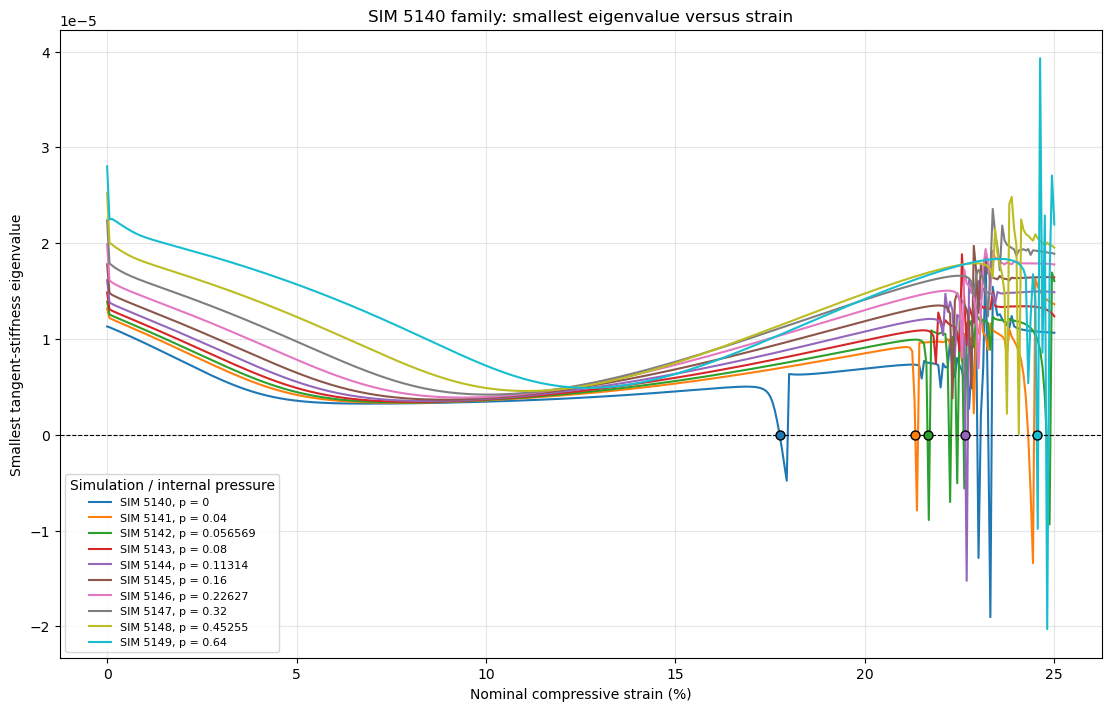

First eigenvalue zero crossings for SIM 5140s:
  SIM       pressure   compression ratio   nominal strain
  5140            0          0.70998293       0.17749573
  5141         0.04          0.85325352       0.21331338
  5142    0.0565685          0.86613303       0.21653326
  5144     0.113137          0.90596206       0.22649052
  5149         0.64          0.98146886       0.24536721


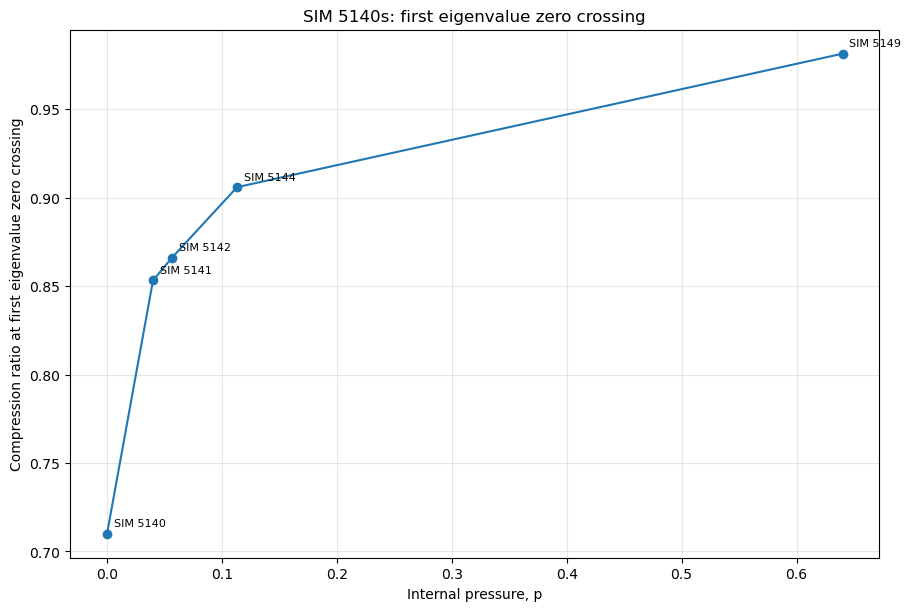

f at first eigenvalue zero crossing for SIM 5140s:
  SIM       pressure   compression ratio       f
  5140            0          0.70998293    0.00000000
  5141         0.04          0.85325352    0.00000000
  5142    0.0565685          0.86613303    0.00000000
  5144     0.113137          0.90596206    0.00000000
  5149         0.64          0.98146886    0.00000000


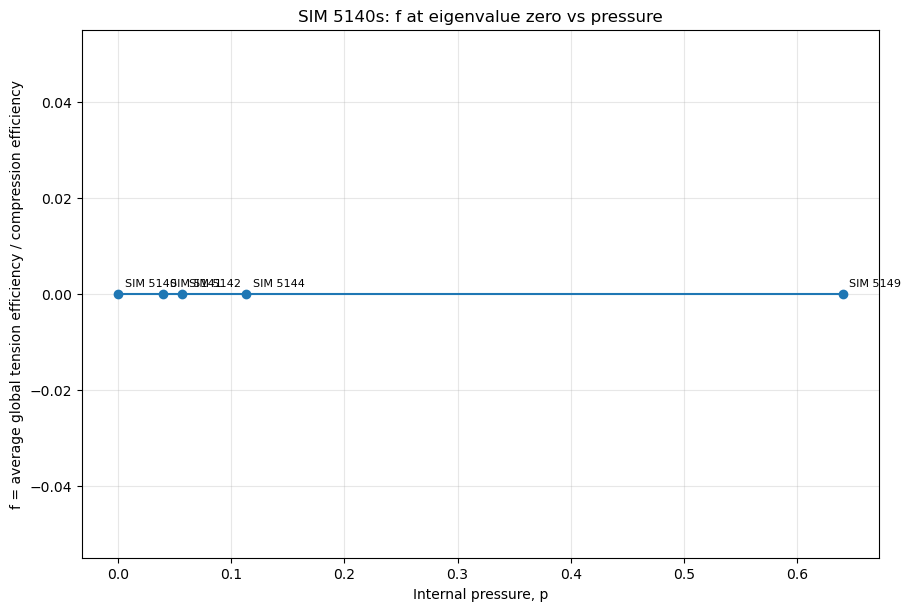

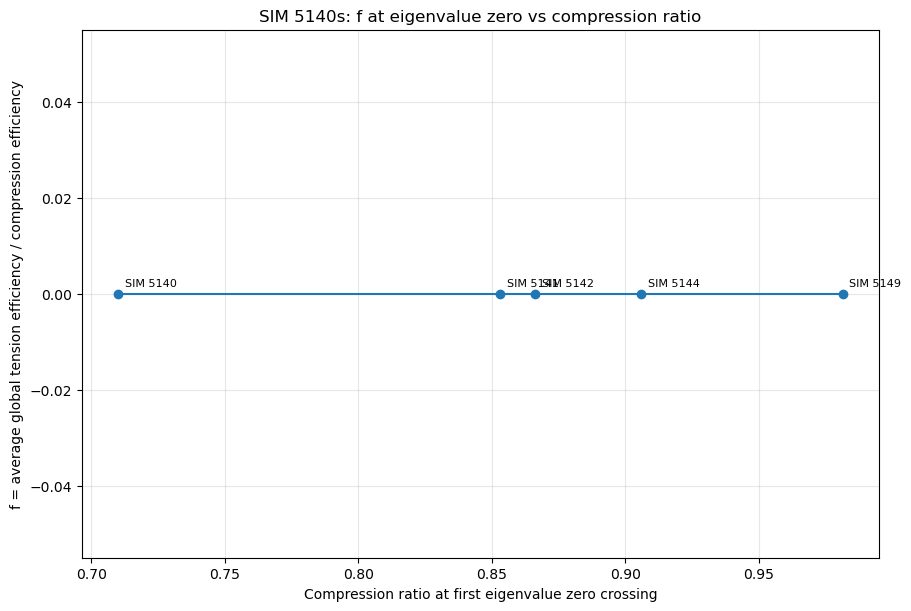

In [3]:
figures = {}

fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)
for sim_id, data in sorted(curves.items()):
    linestyle = '-' if data['complete'] else '--'
    label = f"SIM {sim_id}, p = {data['pressure']:.5g}"
    if not data['complete']:
        label += f" (partial: {len(data['time'])} points)"
    line, = ax.plot(100 * data['strain'], data['lambda_min'], linestyle=linestyle,
                    linewidth=1.5, label=label)
    if np.isfinite(data['crossing_t']):
        ax.scatter(100 * MAX_STRAIN * data['crossing_t'], 0.0,
                   color=line.get_color(), edgecolor='black', s=42, zorder=5)
ax.axhline(0.0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Nominal compressive strain (%)')
ax.set_ylabel('Smallest tangent-stiffness eigenvalue')
ax.set_title('SIM 5140 family: smallest eigenvalue versus strain')
ax.grid(True, alpha=0.3)
if curves:
    ax.legend(title='Simulation / internal pressure', fontsize=8, loc='best')
figures['eigenvalue_strain'] = fig
plt.show()

crossing_rows = np.asarray([
    (sim_id, data['pressure'], data['crossing_t'])
    for sim_id, data in sorted(curves.items())
    if np.isfinite(data['crossing_t'])
], dtype=float).reshape(-1, 3)
f_rows = np.asarray([
    (sim_id, data['pressure'], data['crossing_t'], data['f_at_crossing'])
    for sim_id, data in sorted(curves.items())
    if np.isfinite(data['crossing_t']) and np.isfinite(data['f_at_crossing'])
], dtype=float).reshape(-1, 4)

if len(crossing_rows):
    print('First eigenvalue zero crossings for SIM 5140s:')
    print('  SIM       pressure   compression ratio   nominal strain')
    for sim_id, pressure, compression_ratio in crossing_rows:
        print(f'  {int(sim_id):4d}   {pressure:10.6g}   {compression_ratio:17.8f}'
              f'   {MAX_STRAIN * compression_ratio:14.8f}')
    fig_crossing, ax_crossing = plt.subplots(figsize=(9, 6), constrained_layout=True)
    ax_crossing.plot(crossing_rows[:, 1], crossing_rows[:, 2], 'o-', linewidth=1.5)
    for sim_id, pressure, compression_ratio in crossing_rows:
        ax_crossing.annotate(f'SIM {int(sim_id)}', (pressure, compression_ratio),
                               xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax_crossing.set_xlabel('Internal pressure, p')
    ax_crossing.set_ylabel('Compression ratio at first eigenvalue zero crossing')
    ax_crossing.set_title('SIM 5140s: first eigenvalue zero crossing')
    ax_crossing.grid(True, alpha=0.3)
    figures['crossing_pressure'] = fig_crossing
    plt.show()
else:
    print('No zero crossing was found for the available SIM 5140s curves.')

if len(f_rows):
    print('f at first eigenvalue zero crossing for SIM 5140s:')
    print('  SIM       pressure   compression ratio       f')
    for sim_id, pressure, compression_ratio, f_value in f_rows:
        print(f'  {int(sim_id):4d}   {pressure:10.6g}   {compression_ratio:17.8f}'
              f'   {f_value: .8f}')
    for key, x_column, xlabel, title_tail in [
        ('f_pressure', 1, 'Internal pressure, p', 'vs pressure'),
        ('f_ratio', 2, 'Compression ratio at first eigenvalue zero crossing',
         'vs compression ratio'),
    ]:
        fig_f, ax_f = plt.subplots(figsize=(9, 6), constrained_layout=True)
        ax_f.plot(f_rows[:, x_column], f_rows[:, 3], 'o-', linewidth=1.5)
        for row in f_rows:
            ax_f.annotate(f'SIM {int(row[0])}', (row[x_column], row[3]),
                          xytext=(5, 5), textcoords='offset points', fontsize=8)
        ax_f.set_xlabel(xlabel)
        ax_f.set_ylabel('f = average global tension efficiency / compression efficiency')
        ax_f.set_title(f'SIM 5140s: f at eigenvalue zero {title_tail}')
        ax_f.grid(True, alpha=0.3)
        figures[key] = fig_f
        plt.show()
else:
    print('No valid f values were found at SIM 5140s zero crossings.')


In [4]:
# Save all generated figures in the current notebook working directory.
output_names = {
    'eigenvalue_strain': 'SIM_5140s_smallest_eigenvalue_vs_strain.png',
    'crossing_pressure': 'SIM_5140s_first_eigenvalue_zero_crossing_vs_pressure.png',
    'f_pressure': 'SIM_5140s_f_at_eigenvalue_zero_vs_pressure.png',
    'f_ratio': 'SIM_5140s_f_at_eigenvalue_zero_vs_compression_ratio.png',
}
for figure_key, figure in figures.items():
    output_path = Path(output_names[figure_key])
    figure.savefig(output_path, dpi=200, bbox_inches='tight')
    print(f'Saved: {output_path.resolve()}')


Saved: /Disk_F/FOAM_V03/Z001_Results_Analizer/SIM_5140s_smallest_eigenvalue_vs_strain.png
Saved: /Disk_F/FOAM_V03/Z001_Results_Analizer/SIM_5140s_first_eigenvalue_zero_crossing_vs_pressure.png
Saved: /Disk_F/FOAM_V03/Z001_Results_Analizer/SIM_5140s_f_at_eigenvalue_zero_vs_pressure.png
Saved: /Disk_F/FOAM_V03/Z001_Results_Analizer/SIM_5140s_f_at_eigenvalue_zero_vs_compression_ratio.png
